In [2]:
import os, sys

ROOT= os.path.expanduser('~/QIAO0042/models/ineedfood/')
os.chdir(ROOT)

print('Working dir:', os.getcwd())

Working dir: /scratch-share/QIAO0042/models/ineedfood


In [3]:
import wandb
import matplotlib.pyplot as plt

WANDB_ENTITY  = '584832452-nanyang-technological-university-singapore'
WANDB_PROJECT = 'ineedfood'

def fetch_history(run_id, tag=None):
    """
    Retrieve training history from a wandb run, matching the dict format
    returned by run_training:
        {'train_loss': [...], 'val_loss': [...],
         'train_acc':  [...], 'val_acc':  [...]}

    Parameters
    ----------
    run_id : str
        Short run ID (e.g. 'tin2g81l') or full 'entity/project/run_id'.
    tag : str, optional
        Metric prefix logged as '{tag}/train_loss' etc.
        If None, auto-detected. Pass tag='' for bare keys.

    Returns
    -------
    history : dict  – same structure as run_training output
    config  : dict  – hyperparameters stored in the run config
    """
    api  = wandb.Api()
    path = run_id if '/' in run_id else f'{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}'
    run  = api.run(path)

    df = run.history(samples=10_000, pandas=True)

    # ── Auto-detect tag prefix ────────────────────────────────────────────────
    if tag is None:
        prefixed = [c for c in df.columns if c.endswith('/train_loss')]
        tag = prefixed[0].replace('/train_loss', '') if prefixed else ''

    prefix = f'{tag}/' if tag else ''
    keys = {
        'train_loss': f'{prefix}train_loss',
        'val_loss':   f'{prefix}val_loss',
        'train_acc':  f'{prefix}train_acc',
        'val_acc':    f'{prefix}val_acc',
    }

    missing = [v for v in keys.values() if v not in df.columns]
    if missing:
        available_tags = list({c.rsplit('/', 1)[0] for c in df.columns if '/' in c})
        raise KeyError(
            f"Keys {missing} not found in run '{run.name}'.\n"
            f"  Available tags : {available_tags}\n"
            f"  All keys       : {sorted(df.columns.tolist())}\n"
            f"  Hint: pass tag= explicitly, e.g. fetch_history('{run_id}', tag='{available_tags[0] if available_tags else ''}')"
        )

    sub = df[list(keys.values())].dropna()
    history = {k: sub[v].tolist() for k, v in keys.items()}

    # run.config values are plain Python objects via the API
    config = {k: v for k, v in run.config.items() if not k.startswith('_')}

    print(f"Run  : {run.name}  ({run.id})")
    print(f"Tag  : '{tag}'  |  Steps recovered: {len(sub)}")
    print(f"Config: {config}")
    return history, config


def list_runs(name_filter=None):
    """Print a table of all runs in the project."""
    api  = wandb.Api()
    runs = api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}')
    print(f'{"ID":>10}  {"Name":<30}  {"State":>8}  {"Steps":>6}')
    print('-' * 62)
    for r in runs:
        if name_filter and name_filter not in r.name:
            continue
        steps = r.summary.get('_step', '?')
        print(f'{r.id:>10}  {r.name:<30}  {r.state:>8}  {steps!s:>6}')

def plot_curves(histories, labels, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, linestyle='-',  label=f'{lbl} train')
        axes[0].plot(epochs, hist['val_loss'],   color=c, linestyle='--', label=f'{lbl} val')
        axes[1].plot(epochs, hist['train_acc'],  color=c, linestyle='-',  label=f'{lbl} train')
        axes[1].plot(epochs, hist['val_acc'],    color=c, linestyle='--', label=f'{lbl} val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

print('wandb history utilities ready.')

wandb history utilities ready.


In [4]:
list_runs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.


        ID  Name                               State   Steps
--------------------------------------------------------------
  uozjz9kt  sec3-lr-search                  finished      44
  utghr67i  sec3-lr=0.1                     finished      14
  24p8jikf  sec3-lr=0.025                   finished      14
  ffpy4gb8  sec3-lr=0.001                   finished      14
  ebbk4dtx  sec3-lr=0.1                     finished      14
  bbph2f3s  sec3-lr=0.025                   finished      14
  0ki1ri4a  sec3-lr=0.001                   finished      14
  32e80fkr  sec4-constant-lr                finished     299
  dbwxp3o2  sec4-cosine-anneal              finished     299
  1e9bux0p  sec5-wd=0.0005                  finished     299
  83fad58g  sec5-wd=0.0001                   crashed       9
  mafb82ab  sec5-wd=0.0001                  finished       ?
  tin2g81l  sec5-wd=0.0001                  finished     299
  jw6dlh6h  sec6-no-mixup                   finished       4
  zcdbwlvk  sec6-mixup

In [5]:
hist1, _ = fetch_history('1e9bux0p')
hist2, _ = fetch_history('zcdbwlvk')

Run  : sec5-wd=0.0005  (1e9bux0p)
Tag  : 'WD=0.0005'  |  Steps recovered: 300
Config: {'lr': 0.025, 'model': 'EfficientNet-B0', 'epochs': 300, 'section': 5, 'momentum': 0.9, 'schedule': 'cosine', 'optimizer': 'SGD', 'batch_size': 128, 'weight_decay': 0.0005}
Run  : sec6-mixup-a0.2  (zcdbwlvk)
Tag  : 'Mixup'  |  Steps recovered: 300
Config: {'lr': 0.025, 'mixup': True, 'model': 'EfficientNet-B0', 'epochs': 300, 'section': 6, 'momentum': 0.9, 'schedule': 'cosine', 'optimizer': 'SGD', 'batch_size': 128, 'mixup_alpha': 0.2, 'weight_decay': 0.0005}


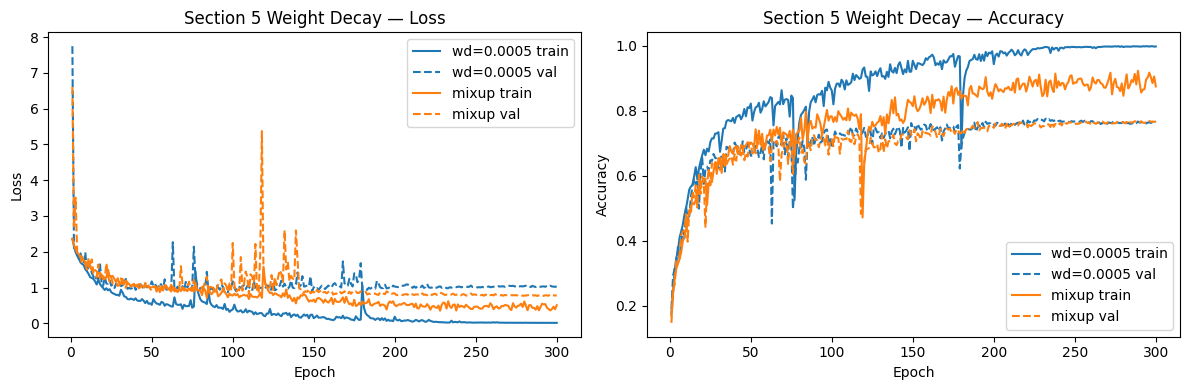

In [8]:
# Compare: no weight decay (cosine, Section 4) vs two WD values
plot_curves(
    histories=[hist1, hist2],
    labels   =['wd=0.0005', 'mixup'],
    title='Section 5 Weight Decay'
)